In [1]:
# import packages
import os
import pysam
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from collections import defaultdict

In [2]:
# path to bam
bam = 'Aligned.sortedByCoord.out.dedup.bam'


In [3]:
def bin_chromosome_se(bam_path, bin_size=500_000):
    bam = pysam.AlignmentFile(bam_path, 'rb')
    counts = defaultdict(lambda: defaultdict(lambda: defaultdict(lambda: {'count': 0, 'coverage': 0})))

    for read in bam.fetch(until_eof=True):

        if read.is_unmapped:
            continue
        if read.is_secondary or read.is_supplementary:
            continue
        if read.has_tag('NH') and read.get_tag('NH') > 1:
            continue
        if not read.has_tag('nM') or read.get_tag('nM') >= 1:
            continue
        if not read.has_tag('AS') or read.get_tag('AS') < 110:
            continue

        # CB and not '-'
        try:
            cb = read.get_tag('CB')
            if cb == '-':
                continue
        except KeyError:
            continue

        chrom = read.reference_name
        start = read.reference_start
        end = read.reference_end
        strand = read.is_reverse

        # bin by start coordinate
        bin_idx = start // bin_size
        bin_start = bin_idx * bin_size
        bin_end = (bin_idx + 1) * bin_size

        # overlap of this read with its bin
        overlap = max(0, min(end, bin_end) - max(start, bin_start))

        bin_entry = counts[cb][chrom][bin_idx]
        bin_entry['count'] += 1
        bin_entry['coverage'] += overlap

    bam.close()

    # build a dataframe
    records = []
    for cb, chrom_bins in counts.items():
        for chrom, bins in chrom_bins.items():
            for bin_idx, vals in bins.items():
                records.append({
                    'CB': cb,
                    'chrom': chrom,
                    'bin': bin_idx,
                    'start': bin_idx * bin_size,
                    'end': (bin_idx + 1) * bin_size,
                    'count': vals['count'],
                    'coverage': vals['coverage']
                })

    df = pd.DataFrame(records)
    return df


In [4]:
# index bam
if not os.path.exists(bam + '.bai'):
    pysam.index(bam)

# bin
res = bin_chromosome_se(
    bam
)

In [5]:
# summarise
res_sum = (
    res
    .assign(origin_chrom=res['chrom'].str.split('_', n=1))
    .assign(
        origin=lambda x: x['origin_chrom'].str[0],
        chrom=lambda x: x['origin_chrom'].str[1]
    )
    .drop(columns='origin_chrom')
    .query("origin in ['GRCh38', 'GRCm39']")
    .groupby(['CB', 'origin'], as_index=False)['count'].sum()
    .pivot(index='CB', columns='origin', values='count')
    .fillna(0)
    .astype(int)
    .reindex(columns=['GRCh38', 'GRCm39'], fill_value=0)
    .assign(
        total_counts=lambda x: x[['GRCh38', 'GRCm39']].sum(axis=1),
        pct_counts_GRCh38=lambda x: (x['GRCh38'] / x['total_counts']) * 100,
        pct_counts_GRCm39=lambda x: (x['GRCm39'] / x['total_counts']) * 100,
    )
    .assign(
        species=lambda x: x.apply(
            lambda row: 'human' if row['pct_counts_GRCh38'] >= 90 else
                        'mouse' if row['pct_counts_GRCm39'] >= 90 else
                        'mixed',
            axis=1
        )
    )
)

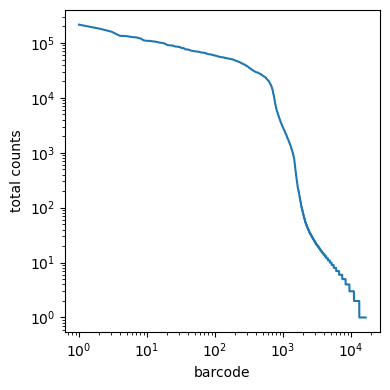

In [6]:
# ranked barcode plot
df_sorted = (
    res_sum
    .assign(
        cb = lambda x: x.index
    )
    .sort_values(
        by='total_counts', ascending=False
    )
    .reset_index(drop=True)
    .assign(
        barcode_index = lambda x: x.index + 1
    )
)

# plot
plt.figure(figsize=(4, 4))
sns.lineplot(
    data=df_sorted,
    x='barcode_index',
    y='total_counts',
    lw=1.5
)
plt.yscale('log')
plt.xscale('log')
plt.ylabel('total counts', fontsize=10)
plt.xlabel('barcode', fontsize=10)
plt.tick_params(axis='both', which='major', labelsize=10)
plt.tight_layout()
plt.show()

Text(0, 0.5, '# reads from bin')

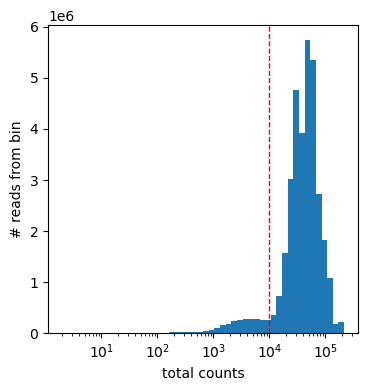

In [7]:
# data
x = res_sum['total_counts'] 
xmin = x.min() + 1
xmax = x.max()

# histogram binning
bins = np.logspace(np.log10(xmin), np.log10(xmax), 51)
hs, bins = np.histogram(x, bins=bins)

# bin edges
lefts = bins[:-1]
rights = bins[1:]

# plot
plt.figure(figsize=(4, 4))
plt.bar(
    x=lefts,
    width=rights - lefts,
    height=hs * rights,
    align='edge',
    lw=0.,
)
plt.xscale('log') 
plt.tick_params(axis='both', which='major', labelsize=10)
plt.axvline(1e4, color='red', linewidth=1, linestyle='--')
plt.xlabel('total counts')
plt.ylabel('# reads from bin')

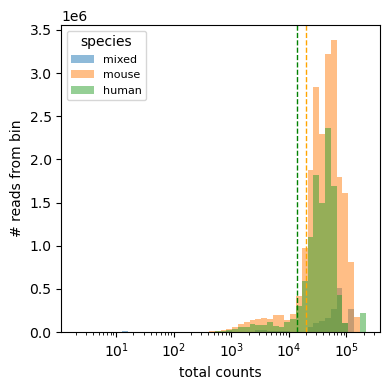

In [8]:
x = res_sum['total_counts']
xmin = x.min() + 1
xmax = x.max()
bins = np.logspace(np.log10(xmin), np.log10(xmax), 51)

plt.figure(figsize=(4, 4))

species_list = res_sum['species'].unique()
colors = plt.cm.tab10.colors

for idx, species in enumerate(species_list):
    x_species = res_sum.loc[res_sum['species'] == species, 'total_counts']
    hs, _ = np.histogram(x_species, bins=bins)
    lefts = bins[:-1]
    rights = bins[1:]
    plt.bar(
        x=lefts,
        width=rights - lefts,
        height=hs * rights,
        align='edge',
        lw=0.,
        alpha=0.5,
        color=colors[idx % len(colors)],
        label=str(species)
    )

plt.xscale('log')
plt.tick_params(axis='both', which='major', labelsize=10)
plt.axvline(1.4e4, color='green', linewidth=1, linestyle='--')
plt.axvline(2e4, color='orange', linewidth=1, linestyle='--')
plt.xlabel('total counts')
plt.ylabel('# reads from bin')
plt.legend(title='species', fontsize=8)
plt.tight_layout()
plt.show()

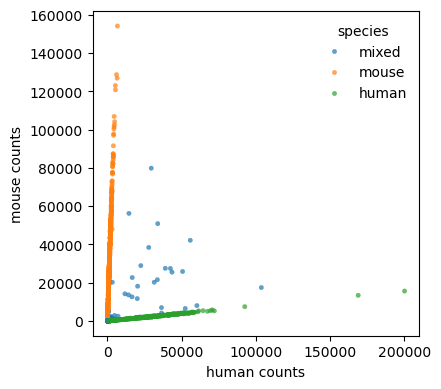

In [9]:
# species mixing scatter plot
plt.figure(figsize=(4.5, 4))
ax = sns.scatterplot(
    data=res_sum,
    x='GRCh38',
    y='GRCm39',
    alpha=0.7,
    edgecolor=None,
    hue='species',
    s=10
)
plt.xlabel('human counts')
plt.ylabel('mouse counts')

ax.legend(loc='upper right', title='species', frameon=False)

plt.tight_layout()
plt.show()


In [12]:
df_qced = df_sorted[
    ((df_sorted['species'] == 'human') & (df_sorted['GRCh38'] >= 1e4)) |
    ((df_sorted['species'] == 'mouse') & (df_sorted['GRCm39'] >= 2e4)) |
    ((df_sorted['species'] == 'mixed') & (df_sorted['total_counts'] >= 1e4))
].copy()

print(df_qced['species'].value_counts())

species
mouse    365
human    264
mixed     24
Name: count, dtype: int64


In [13]:
ith open('qced_cell_barcodes_GRCh38.txt', 'w') as f:
    for line in df_qced.loc[df_qced['species'] == 'human']['cb'].tolist():
        f.write(f"{line}\n")

with open('qced_cell_barcodes_GRCm39.txt', 'w') as f:
    for line in df_qced.loc[df_qced['species'] == 'mouse']['cb'].tolist():
        f.write(f"{line}\n")